# Analyzing Multistate Trajectory Files with openfe-analysis

This notebook demonstrates how to load, align, and analyze multistate
trajectory files produced by OpenFE's free energy protocols. We cover
two protocols:

- **Relative Hybrid Topology Protocol (RBFE)**: a single hybrid ligand is used
  to represent both end states. The trajectory contains one ligand
  per frame.
- **Separated Topologies Protocol (SepTop)**: both ligands are present
  simultaneously throughout the simulation. The trajectory contains
  two physically distinct ligands per frame.

Both protocols produce complex (protein + ligand) and solvent
(ligand only) legs, which will be analyzed separately.

## Removal of periodic boundary conditions and alignment operations

Before computing any RMSD-based metric we must:

1. **Unwrap** molecules that have been split across periodic boundary
   conditions (PBC), making each molecule whole again.
2. **Image** molecules into the same periodic image. In a complex
   simulation the ligand may drift into a neighbouring box relative
   to the protein. In SepTop, each ligand must be imaged
   *independently*, since they can cross periodic boundaries at
   different times.
3. **Align** all frames to a common reference (the first frame) by
   minimizing the protein Cα RMSD. This removes overall translational
   and rotational motion so that structural changes reflect internal
   dynamics rather than rigid-body drift.

`openfe-analysis` handles all of this automatically by applying a series of
[MDAnalysis Universe Transformations](https://docs.mdanalysis.org/stable/documentation_pages/trajectory_transformations.html)
on-the-fly as frames are read from the trajectory.

## Structural metrics

The following metrics are computed for each lambda state. The complex and
solvent legs differ in which analyses are meaningful:

**Complex leg (protein + ligand)**

- **2D Protein RMSD**: a pairwise RMSD matrix between all analyzed frames.
  This metric gives, for each lambda state, the RMSD of the
  protein structure over time, using each frame analysed as a reference frame, to produce a 2 dimensional heatmap.
  This plot should show no significant spikes in RMSD (which will appear as brightly coloured areas).
  
- **Ligand RMSD**: measures how much the ligand moves
  relative to its starting pose in the binding site. Values above ~5 Å
  may indicate the ligand has shifted significantly or left the binding site.
  For the hybrid topology protocol, a standard mass-weighted RMSD is used.
  For SepTop, a symmetry-corrected RMSD is used instead, which accounts
  for equivalent atom orderings in symmetric molecules (e.g. flipping a
  phenyl ring) that would otherwise give a non-zero RMSD for
  physically identical poses. Symmetry correction is not yet applied in
  the hybrid topology protocol because element changes in the B state
  require additional handling before it can be applied correctly.

- **Ligand COM drift**: measures the displacement of the ligand
  centre-of-mass from its initial position. Unlike RMSD, this is purely
  translational and not sensitive to rotations. Sustained drift above ~5 Å
  may indicate the ligand is leaving the binding site.



**Solvent leg (ligand only)**

- **Ligand RMSD**: same as above but without protein context.

For SepTop, all ligand-based metrics are computed independently for both ligand A
and ligand B.

## Download tutorial data

In [1]:
%%bash

# Hybrid topology
wget --show-progress "https://zenodo.org/records/20442933/files/openfe_analysis_skipped.tar.gz" -nc
tar -xzf openfe_analysis_skipped.tar.gz

# SepTop
wget --show-progress "https://zenodo.org/records/20507106/files/septop_structural_results.zip" -nc
tar -xzf septop_structural_results.zip

File 'openfe_analysis_skipped.tar.gz' already there; not retrieving.

File 'septop_structural_results.zip' already there; not retrieving.



## Imports

In [1]:
import pathlib

import matplotlib.pyplot as plt
import MDAnalysis as mda
import netCDF4 as nc
import numpy as np
from rdkit import Chem
from rdkit.Chem import SDMolSupplier

from openfe_analysis.rmsd import (
    LigandCOMDrift,
    Protein2DRMSD,
    RMSDAnalysis,
    SymmetryCorrectedLigandRMSD,
)
from openfe_analysis.utils.apply_transformations import (
    apply_complex_alignment_transformations,
    apply_ligand_alignment_transformations,
)
from openfe_analysis.utils.universe_utils import create_universe_single_state

Let's define the paths to the downloaded tutorial data that we will use throughout this notebook.

In [2]:
rfe_dir = pathlib.Path("openfe_analysis_skipped")
septop_dir = pathlib.Path("septop_structural_results")

# Part 1 — Relative Hybrid Topology Protocol

## Complex leg

### Load trajectory and topology

In [3]:
rfe_complex_pdb = rfe_dir / "hybrid_system.pdb"
rfe_complex_nc = rfe_dir / "simulation.nc"

### Compute structural metrics across all lambda states

We loop over all lambda states, loading each as a separate MDAnalysis
Universe.

In [4]:
rfe_lig_rmsd = []
rfe_lig_com_drift = []
rfe_prot_2d_rmsd = []
rfe_time_ps = None
    
protein_selection = "protein and name CA"
ligand_selection = "resname UNK"
with nc.Dataset(rfe_complex_nc) as ds:
    n_lambda = ds.dimensions["state"].size

    # Account for the position skip rate.
    if hasattr(ds, "PositionInterval"):
        n_frames = len(range(0, ds.dimensions["iteration"].size, ds.PositionInterval))
    else:
        n_frames = ds.dimensions["iteration"].size

    # find skip that would give ~500 frames of output
    # max against 1 to avoid skip=0 case
    skip = max(n_frames // 500, 1)

    u_top = mda.Universe(rfe_complex_pdb)
    
    # Loop over all lambda states
    for state_idx in range(n_lambda):
        # Create an MDAnalysis universe for this state
        universe = create_universe_single_state(u_top._topology, ds, state_idx)
        prot = universe.select_atoms(protein_selection)
        lig = universe.select_atoms(ligand_selection)
        
        # Remove PBC artifacts and align frames
        apply_complex_alignment_transformations(universe, protein=prot, ligands=[lig])

        # Calculate the protein 2D RMSE
        protein_2d_rmsd = Protein2DRMSD(prot).run(step=skip)
        rfe_prot_2d_rmsd.append(protein_2d_rmsd.results.rmsd2d)

        # Calculate the ligand RMSD
        ligand_rmsd = RMSDAnalysis(lig, mass_weighted=True).run(step=skip).results.rmsd
        rfe_lig_rmsd.append(ligand_rmsd)

        # Calculate the Ligand COM drift
        ligand_com_drift = LigandCOMDrift(lig).run(step=skip).results.com_drift
        rfe_lig_com_drift.append(ligand_com_drift)
        
        # Get the time frames
        if rfe_time_ps is None:
            rfe_time_ps = (
                np.arange(len(universe.trajectory))[::skip] * universe.trajectory.dt
            )

### Plot results

Each line represents one lambda state. Consistent profiles across
states indicate a stable, well-behaved simulation. Large deviations
in specific states may indicate sampling problems or instabilities.

In [3]:
from openfe_analysis.utils.plotting import (
    plot_2D_rmsd,
    plot_ligand_RMSD,
    plot_ligand_COM_drift,
)

### Plotting the protein 2D RMSD

A well-behaved simulation shows a uniform low-RMSD matrix (blue tones).
Bright spots or bands indicate the protein visited a distinct conformation.
A gradient from top-left to bottom-right suggests the protein has not
equilibrated.

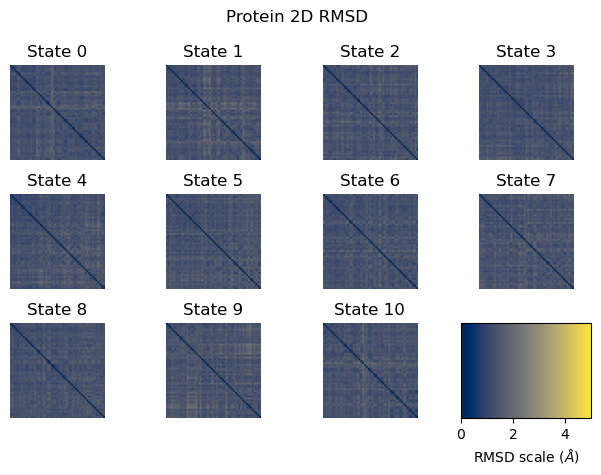

In [6]:
# Protein 2D RMSD — all states in one figure
fig = plot_2D_rmsd(rfe_prot_2d_rmsd)
plt.show()

### Plotting the ligand RMSD

Values consistently below ~3–4 Å indicate a stable ligand pose. Values
above ~5 Å may indicate the ligand binding mode has shifted significantly.

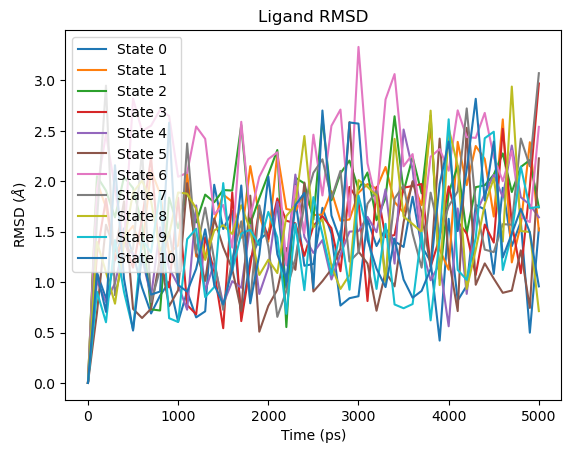

In [7]:
# Ligand RMSD
fig = plot_ligand_RMSD(rfe_time_ps, rfe_lig_rmsd)
plt.show()

### Plotting the ligand center-of-mass drift

Values consistently below ~5 Å indicate the ligand is staying close to
its initial position in the binding site. A sustained increase above ~5 Å
may indicate the ligand is drifting out of the binding site.

Note that the first frame after equilibration is used as a reference, meaning that if the ligand already left the binding site during equilibration, this may not show up in this plot.

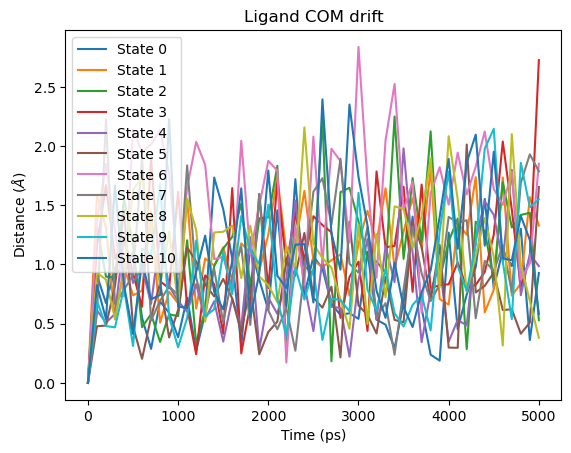

In [8]:
# Ligand COM drift
fig = plot_ligand_COM_drift(rfe_time_ps, rfe_lig_com_drift)
plt.show()

# Part 2 — Separated Topologies (SepTop)

In a SepTop simulation both ligands are present simultaneously
throughout the calculation. Ligand A is coupled at the start of
the lambda schedule while ligand B is decoupled, and the schedule
then decouples A and couples B. We will include both ligands in out structural analysis.

## SepTop Complex leg

### Load trajectory and topology

In [4]:
septop_complex_pdb = septop_dir / "complex" / "alchemical_system.pdb"
septop_complex_nc_file = septop_dir / "complex" / "complex.nc"

rdmol_A = SDMolSupplier(str(septop_dir / "complex" / "ligand_A.sdf"), removeHs=False)[0]
rdmol_B = SDMolSupplier(str(septop_dir / "complex" / "ligand_B.sdf"), removeHs=False)[0]

### Getting ligand indices

In a real SepTop calculation, the ligand indices are stored in
the protocol output JSON and can be extracted from there. For this
tutorial we derive them directly from the topology by residue name, which
works because the two ligands have distinct residue indices within the
same residue name `UNK`.

In [5]:
u_tmp = mda.Universe(septop_complex_pdb)

# Select all UNK residues — in a SepTop system these are the two ligands
unk_residues = u_tmp.select_atoms("resname UNK").residues

septop_ligand_A_indices = unk_residues[0].atoms.indices.tolist()
septop_ligand_B_indices = unk_residues[1].atoms.indices.tolist()

### Compute structural metrics across all lambda states

Unlike the hybrid topology protocol where only one ligand
is present, SepTop has two physically distinct ligands in the same simulation
box, sharing a single universe. 

This means:

- Both ligands must be aligned and imaged for every lambda state.
- Each ligand must be imaged **independently** relative to the protein.
  Both ligands are passed as separate AtomGroups to
  `apply_complex_alignment_transformations` so that `ClosestImageShift`
  corrects each ligand individually. Passing them as a combined AtomGroup
  can cause PBC imaging artifacts when one ligand crosses a periodic boundary
  independently of the other.
- `SymmetryCorrectedLigandRMSD` is used for both ligands since the SepTop
  setup preserves the full atom identity of each molecule, unlike the hybrid
  topology where element changes in the B state require additional handling
  before symmetry correction can be applied correctly.

In [11]:
septop_prot_rmsds = []
septop_lig_A_rmsds = []
septop_lig_B_rmsds = []
septop_lig_A_drifts = []
septop_lig_B_drifts = []
septop_prot_2d_rmsds = []
septop_time_ps = None

with nc.Dataset(septop_complex_nc_file) as ds:
    n_lambda = ds.dimensions["state"].size

    # Account for the position skip rate.
    if hasattr(ds, "PositionInterval"):
        n_frames = len(range(0, ds.dimensions["iteration"].size, ds.PositionInterval))
    else:
        n_frames = ds.dimensions["iteration"].size

    # find skip that would give ~500 frames of output
    # max against 1 to avoid skip=0 case
    septop_skip = max(n_frames // 500, 1)

    u_top = mda.Universe(septop_complex_pdb)
    
    for state_idx in range(n_lambda):
        
        # Create an MDAnalysis universe for this state
        universe = create_universe_single_state(u_top._topology, ds, state_idx)
        prot = universe.select_atoms(protein_selection)
        lig_A = universe.atoms[septop_ligand_A_indices]
        lig_B = universe.atoms[septop_ligand_B_indices]

        # Remove PBC artifacts and align frames
        apply_complex_alignment_transformations(universe, protein=prot, ligands=[lig_A, lig_B])

        # Calculate the protein 2D RMSD
        septop_prot_2d_rmsds.append(
            Protein2DRMSD(prot).run(step=septop_skip).results.rmsd2d
        )

        # Calculate the symmetry corrected RMSD
        septop_lig_A_rmsds.append(
            SymmetryCorrectedLigandRMSD(lig_A, rdmol=rdmol_A)
            .run(step=septop_skip).results.rmsd
        )
        septop_lig_B_rmsds.append(
            SymmetryCorrectedLigandRMSD(lig_B, rdmol=rdmol_B)
            .run(step=septop_skip).results.rmsd
        )
        # Calculate the Ligand COM drift
        septop_lig_A_drifts.append(
            LigandCOMDrift(lig_A).run(step=septop_skip).results.com_drift
        )
        septop_lig_B_drifts.append(
            LigandCOMDrift(lig_B).run(step=septop_skip).results.com_drift
        )
        

        if septop_time_ps is None:
            septop_time_ps = (
                np.arange(len(universe.trajectory))[::septop_skip] * universe.trajectory.dt
            )

### Plot the protein 2D RMSD

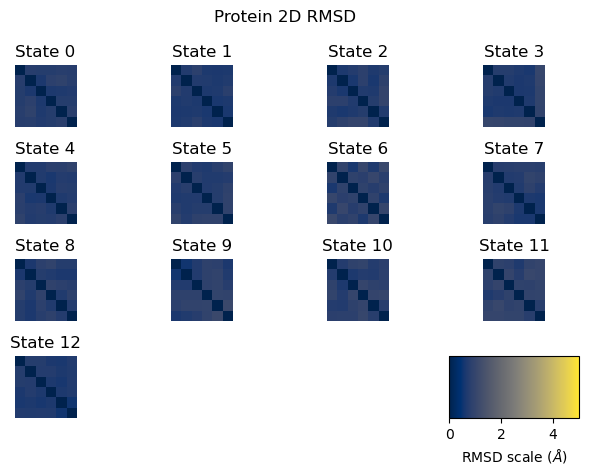

In [12]:
fig = plot_2D_rmsd(septop_prot_2d_rmsds)
plt.show()

### Plot the RMSD of ligand A and ligand B

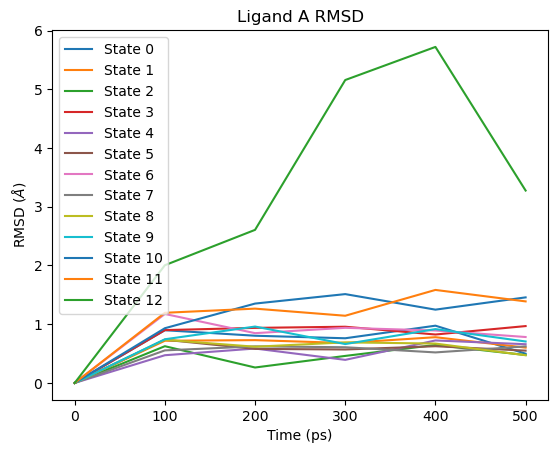

In [13]:
# Ligand A RMSD
fig = plot_ligand_RMSD(septop_time_ps, septop_lig_A_rmsds)
fig.axes[0].set_title("Ligand A RMSD")
plt.show()

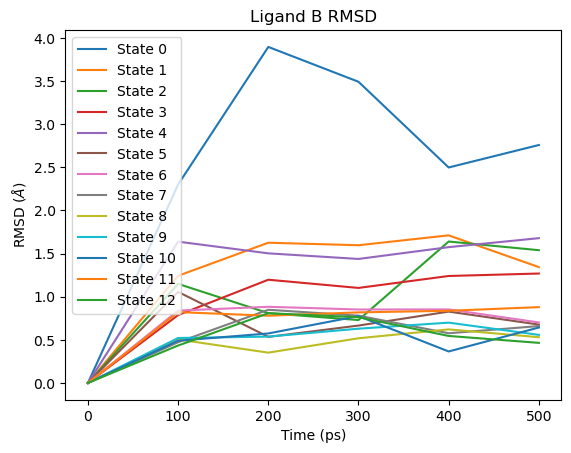

In [14]:
# Ligand B RMSD
fig = plot_ligand_RMSD(septop_time_ps, septop_lig_B_rmsds)
fig.axes[0].set_title("Ligand B RMSD")
plt.show()

### Plot the ligand center-of-mass drift for both ligand A and ligand B

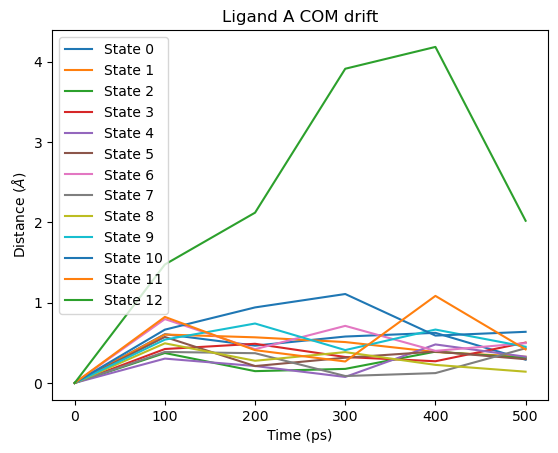

In [15]:
# Ligand A COM drift
fig = plot_ligand_COM_drift(septop_time_ps, septop_lig_A_drifts)
fig.axes[0].set_title("Ligand A COM drift")
plt.show()

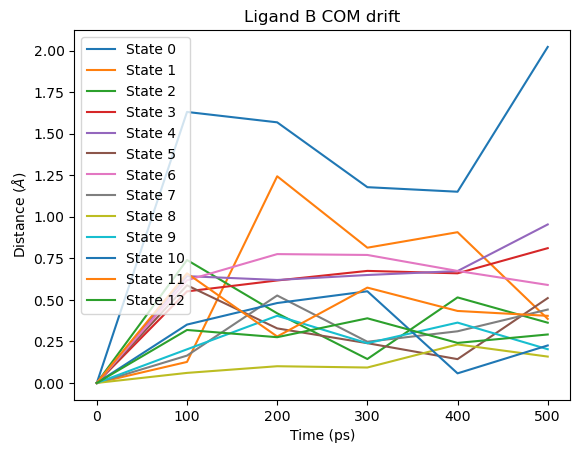

In [16]:
# Ligand B COM drift
fig = plot_ligand_COM_drift(septop_time_ps, septop_lig_B_drifts)
fig.axes[0].set_title("Ligand B COM drift")
plt.show()

## SepTop Solvent leg

### Load trajectory and topology

In [6]:
septop_solvent_pdb = septop_dir / "solvent" / "alchemical_system.pdb"
septop_solvent_nc_file = septop_dir / "solvent" / "solvent.nc"

### Getting ligand indices

In a real SepTop calculation, the ligand indices are stored in the protocol
output JSON and can be extracted from there (see the complex leg section above
for how to do this). For this tutorial we derive them from the topology
directly.

In the solvent leg, both ligands are present in the same subsampled PDB as a
single residue with the name `UNK`. We know the atom count of each ligand from
the complex leg indices we already extracted, so we can use those to slice the
solvent `UNK` atoms — ligand A occupying the first `n_atoms_A` atoms and
ligand B the remaining `n_atoms_B` atoms. We verify this assumption with an
assert before proceeding.

In [7]:
n_atoms_A = len(septop_ligand_A_indices)
n_atoms_B = len(septop_ligand_B_indices)

u_tmp_solvent = mda.Universe(septop_solvent_pdb)
unk_solvent = u_tmp_solvent.select_atoms("resname UNK")
print(f"Solvent UNK atoms: {unk_solvent.n_atoms}")
print(f"Expected: {n_atoms_A} (ligand A) + {n_atoms_B} (ligand B) = {n_atoms_A + n_atoms_B}")

assert unk_solvent.n_atoms == n_atoms_A + n_atoms_B, (
    f"Unexpected atom count: {unk_solvent.n_atoms}"
)

# Ligand A comes first, ligand B second
septop_solvent_ligand_A_indices = unk_solvent.indices[:n_atoms_A].tolist()
septop_solvent_ligand_B_indices = unk_solvent.indices[n_atoms_A:].tolist()

print(f"Ligand A indices: {septop_solvent_ligand_A_indices[0]}–{septop_solvent_ligand_A_indices[-1]}")
print(f"Ligand B indices: {septop_solvent_ligand_B_indices[0]}–{septop_solvent_ligand_B_indices[-1]}")

Solvent UNK atoms: 75
Expected: 37 (ligand A) + 38 (ligand B) = 75
Ligand A indices: 0–36
Ligand B indices: 37–74


### Compute structural metrics across all lambda states

In the solvent leg we create a separate universe for each ligand. This is
necessary because `apply_ligand_alignment_transformations` uses `NoJump`
to prevent the ligand from jumping between periodic images by tracking its
centre-of-mass motion continuously across frames. If both ligands shared
a universe, the transformation applied to one would affect the coordinate
frame seen by the other.

In [8]:
septop_solvent_lig_A_rmsds = []
septop_solvent_lig_B_rmsds = []
septop_solvent_time_ps = None

with nc.Dataset(septop_solvent_nc_file) as ds:
    n_lambda = ds.dimensions["state"].size
    if hasattr(ds, "PositionInterval"):
        n_frames = len(range(0, ds.dimensions["iteration"].size, ds.PositionInterval))
    else:
        n_frames = ds.dimensions["iteration"].size
    septop_solvent_skip = max(n_frames // 500, 1)

u_top_solvent = mda.Universe(septop_solvent_pdb)

for state_idx in range(n_lambda):
    # Ligand A: independent universe and alignment
    universe_A = create_universe_single_state(
        u_top_solvent._topology, septop_solvent_nc_file, state_idx
    )
    lig_A = universe_A.atoms[septop_solvent_ligand_A_indices]
    apply_ligand_alignment_transformations(universe_A, ligand=lig_A)
    septop_solvent_lig_A_rmsds.append(
        SymmetryCorrectedLigandRMSD(lig_A, rdmol=rdmol_A)
        .run(step=septop_solvent_skip).results.rmsd
    )

    # Ligand B: separate universe so NoJump tracks it independently
    universe_B = create_universe_single_state(
        u_top_solvent._topology, septop_solvent_nc_file, state_idx
    )
    lig_B = universe_B.atoms[septop_solvent_ligand_B_indices]
    apply_ligand_alignment_transformations(universe_B, ligand=lig_B)
    septop_solvent_lig_B_rmsds.append(
        SymmetryCorrectedLigandRMSD(lig_B, rdmol=rdmol_B)
        .run(step=septop_solvent_skip).results.rmsd
    )

    if septop_solvent_time_ps is None:
        septop_solvent_time_ps = (
            np.arange(len(universe_A.trajectory))[::septop_solvent_skip]
            * universe_A.trajectory.dt
        )

### Plot the ligand RMSD

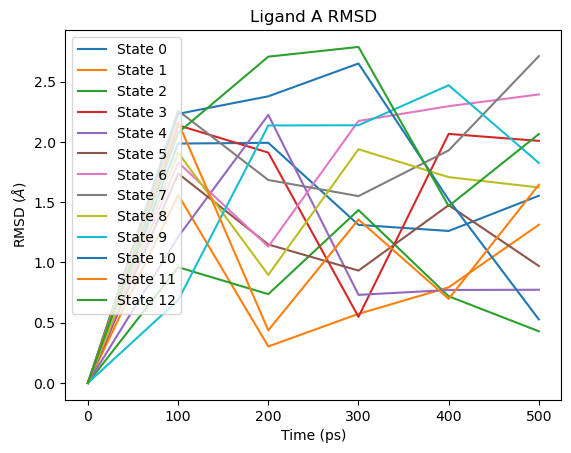

In [9]:
# Ligand A RMSD
fig = plot_ligand_RMSD(septop_solvent_time_ps, septop_solvent_lig_A_rmsds)
fig.axes[0].set_title("Ligand A RMSD")
plt.show()

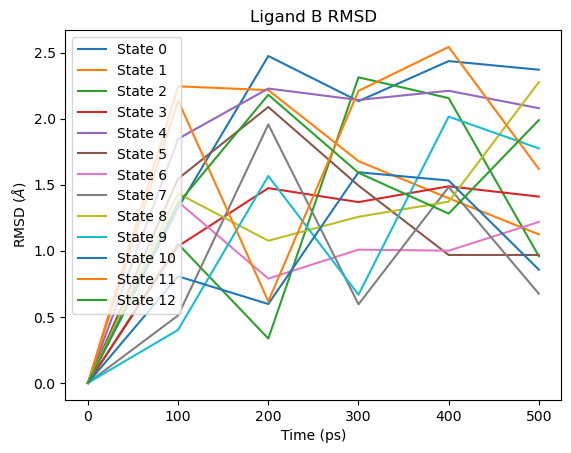

In [10]:
# Ligand B RMSD
fig = plot_ligand_RMSD(septop_solvent_time_ps, septop_solvent_lig_B_rmsds)
fig.axes[0].set_title("Ligand B RMSD")
plt.show()